<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week5/Day3/Dailychallenges/defi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Défi quotidien : Classification de chiffres manuscrits à l'aide de réseaux de neurones convolutifs (CNN)

--- Étape 1 : Chargement de l'ensemble de données MNIST ---
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Forme des images d'entraînement : (60000, 28, 28)
Forme des étiquettes d'entraînement : (60000,)
Forme des images de test         : (10000, 28, 28)

--- Étape 2 : Prétraitement pour le réseau Entièrement Connecté (ANN) ---

--- Étape 3 : Construction et entraînement de l'ANN (Dense) ---
Entraînement de l'ANN...
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9202 - loss: 0.2794 - val_accuracy: 0.9617 - val_loss: 0.1342
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9661 - loss: 0.1148 - val_accuracy: 0.9689 - val_loss: 0.1005
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9768 - loss: 0.0769 - val_accuracy: 0.9703 - val_loss: 0.0913
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9831 - loss: 0.0561 - val_accuracy: 0.9720 - val_loss: 0.0872
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.987

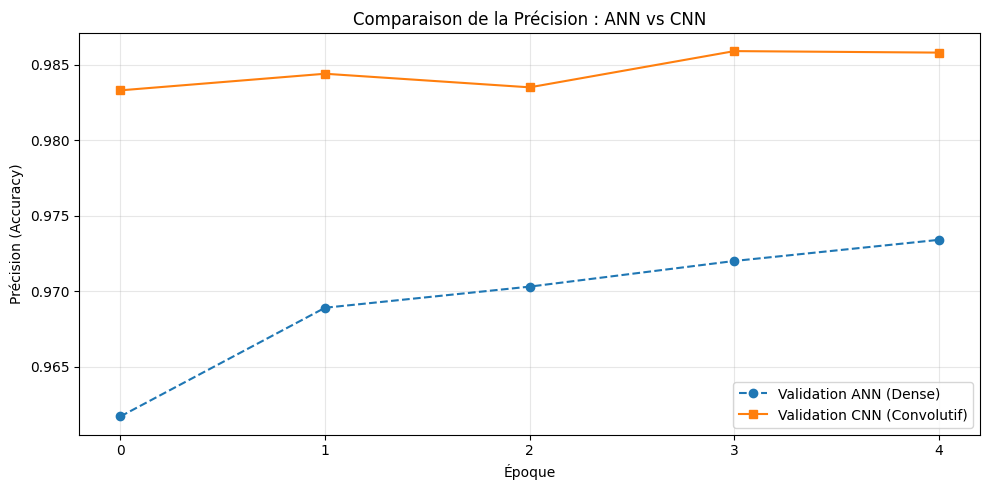

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

# =====================================================================
# 1. CHARGEMENT ET INSPECTION DE L'ENSEMBLE DE DONNÉES MNIST
# =====================================================================
print("--- Étape 1 : Chargement de l'ensemble de données MNIST ---")
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = mnist.load_data()

print(f"Forme des images d'entraînement : {x_train_raw.shape}") # (60000, 28, 28)
print(f"Forme des étiquettes d'entraînement : {y_train_raw.shape}") # (60000,)
print(f"Forme des images de test         : {x_test_raw.shape}") # (10000, 28, 28)

# =====================================================================
# 2. PRÉTRAITEMENT POUR LE RÉSEAU ENTIÈREMENT CONNECTÉ (ANN)
# =====================================================================
print("\n--- Étape 2 : Prétraitement pour le réseau Entièrement Connecté (ANN) ---")

# Normalisation des pixels [0, 255] -> [0, 1] et aplatissement systématique (28x28 -> 784)
x_train_ann = x_train_raw.reshape(60000, 784).astype("float32") / 255.0
x_test_ann  = x_test_raw.reshape(10000, 784).astype("float32") / 255.0

# Encodage One-Hot des cibles (Correction du chemin d'importation Keras moderne)
y_train_oh = to_categorical(y_train_raw, num_classes=10)
y_test_oh  = to_categorical(y_test_raw, num_classes=10)

# =====================================================================
# 3. ARCHITECTURE ET ENTRAÎNEMENT DU RÉSEAU ENTIÈREMENT CONNECTÉ (ANN)
# =====================================================================
print("\n--- Étape 3 : Construction et entraînement de l'ANN (Dense) ---")
tf.random.set_seed(42)

ann_model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Entraînement de l'ANN...")
ann_history = ann_model.fit(
    x_train_ann, y_train_oh,
    epochs=5,
    batch_size=64,
    validation_data=(x_test_ann, y_test_oh),
    verbose=1
)

# =====================================================================
# 4. PRÉTRAITEMENT POUR LE RÉSEAU NEURONAL CONVOLUTIF (CNN)
# =====================================================================
print("\n--- Étape 4 : Prétraitement pour le Réseau Convolutif (CNN) ---")

# Redimensionnement à la forme attendue par Conv2D : (Nb_images, hauteur, largeur, canaux)
x_train_cnn = x_train_raw.reshape(60000, 28, 28, 1).astype("float32") / 255.0
x_test_cnn  = x_test_raw.reshape(10000, 28, 28, 1).astype("float32") / 255.0

# =====================================================================
# 5. ARCHITECTURE ET ENTRAÎNEMENT DU RÉSEAU CONVOLUTIF (CNN)
# =====================================================================
print("\n--- Étape 5 : Construction et entraînement du CNN ---")

cnn_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # Premier bloc Convolutif
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Deuxième bloc Convolutif
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Aplatissement et classification
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Entraînement du CNN...")
cnn_history = cnn_model.fit(
    x_train_cnn, y_train_oh,
    epochs=5,
    batch_size=64,
    validation_data=(x_test_cnn, y_test_oh),
    verbose=1
)

# =====================================================================
# 6. COMPARAISON ET VISUALISATION DES PERFORMANCES FINALES
# =====================================================================
print("\n--- Étape 6 : Analyse comparative des deux architectures ---")

ann_loss, ann_acc = ann_model.evaluate(x_test_ann, y_test_oh, verbose=0)
cnn_loss, cnn_acc = cnn_model.evaluate(x_test_cnn, y_test_oh, verbose=0)

print("="*60)
print(f"• Réseau Entièrement Connecté (ANN) | Test Accuracy : {ann_acc*100:.2f} %")
print(f"• Réseau Neuronal Convolutif (CNN)   | Test Accuracy : {cnn_acc*100:.2f} %")
print("="*60)

# Tracé des courbes de précision pour le rapport d'analyse
plt.figure(figsize=(10, 5))
plt.plot(ann_history.history['val_accuracy'], label='Validation ANN (Dense)', linestyle='--', marker='o')
plt.plot(cnn_history.history['val_accuracy'], label='Validation CNN (Convolutif)', marker='s')
plt.title("Comparaison de la Précision : ANN vs CNN")
plt.xlabel("Époque")
plt.ylabel("Précision (Accuracy)")
plt.xticks(range(5))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Analyse comparative des performances : ANN vs CNN

L'analyse des courbes d'apprentissage met en évidence une supériorité nette du Réseau de Neurones Convolutif (CNN) par rapport au Réseau Entièrement Connecté (ANN).

#### 1. Constats graphiques
- **Réseau Entièrement Connecté (ANN)** : Sa précision de validation débute autour de 96,1 % et progresse de manière linéaire pour stagner en fin de course aux alentours de 97,3 %.
- **Réseau Convolutif (CNN)** : Dès la première époque, le CNN surpasse le niveau maximal de l'ANN avec une précision initiale de 98,3 %, pour finir par se stabiliser au score optimal de 98,6 %.

#### 2. Justification mathématique et structurelle
Cette différence de performance s'explique par deux facteurs fondamentaux liés à l'architecture des réseaux :
- **La préservation de la topologie spatiale** : L'ANN classique force l'aplatissement (Flatten) de l'image de 28x28 en un vecteur linéaire de 784 pixels, détruisant instantanément la relation géométrique de proximité entre les pixels voisins. À l'inverse, les couches `Conv2D` du CNN scannent l'image à l'aide de fenêtres glissantes bidimensionnelles, ce qui permet de préserver et d'extraire les structures locales (lignes, boucles, croisements des chiffres).
- **L'invariance aux translations** : Les chiffres manuscrits présentent de légères déformations ou des décalages de centrage. Grâce aux couches de sous-échantillonnage `MaxPooling2D`, le CNN développe une robustesse face à ces variations spatiales, tandis que l'ANN peine à généraliser si un motif est légèrement déplacé par rapport à sa position dans les données d'entraînement.

**Conclusion** : Le CNN est l'architecture de référence pour le traitement d'images car il capture efficacement les descripteurs visuels tout en limitant le surapprentissage grâce au partage des poids.
